# ***1) Importing libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
from transformers import pipeline

# ***2) Importing DataSet***

In [3]:
df = pd.read_csv("/content/data_urls_final.csv")

# ***3) Exploratory data analysis (EDA)***

In [4]:
df.shape

(981, 88)

### **Comment**: 11357 rows and 88 columns

In [5]:
df.head()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,PopularUserTags,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,"Action, FPS, Multiplayer, Shooter, Classic, Te...",1.0,Community_Social,28138.0,1.0,50690.0,1.0,Small,2000.0,NaN
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,"Action, FPS, Multiplayer, Classic, Hero Shoote...",0.0,NaN,30412.0,1.0,64709.0,1.0,Small,1999.0,NaN
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,"FPS, World War II, Multiplayer, Shooter, Actio...",0.0,NaN,36605.0,1.0,58479.0,1.0,Medium,2003.0,Custom_Studio
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",0.0,NaN,32228.0,1.0,39026.0,1.0,Small,2001.0,NaN
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,"FPS, Action, Classic, Sci-fi, Singleplayer, Sh...",0.0,NaN,41595.0,1.0,37607.0,1.0,Medium,1999.0,NaN


In [6]:
df.tail()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,PopularUserTags,Has_Support_Link,Support_Tier,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,Header_Size_Group,ReleaseYear,Website_Authority
976,47520,47520,The Otherside,The Otherside: Realm of Eons,Feb 11 2010,0,0,1,0,0,...,"Casual, Hidden Object",0.0,NaN,26819.0,1.0,55276.0,1.0,Small,2010.0,Custom_Studio
977,47540,47540,Puzzle Quest 2,Puzzle Quest 2,Aug 12 2010,0,0,1,0,83,...,"RPG, Casual, Puzzle, Match 3, Fantasy, Singlep...",0.0,NaN,48291.0,1.0,111719.0,1.0,Large,2010.0,Custom_Studio
978,47570,47570,Mishap 2: An Intentional Haunting,Mishap 2: An Intentional Haunting - Collectors...,Jan 28 2011,0,0,1,0,0,...,"Casual, Hidden Object",0.0,NaN,50874.0,1.0,47106.0,1.0,Large,2011.0,Custom_Studio
979,47730,47730,Dragon Age: Origins - Awakening,Dragon Age(tm): Origins Awakening,Mar 16 2010,17,0,1,0,82,...,"RPG, Fantasy, Party-Based RPG, Choices Matter,...",0.0,NaN,42551.0,1.0,50867.0,1.0,Medium,2010.0,Custom_Studio
980,47780,47780,Dead Space 2,Dead Space(tm) 2,Jan 25 2011,0,0,1,0,87,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      981 non-null    int64  
 1   ResponseID                   981 non-null    int64  
 2   QueryName                    980 non-null    object 
 3   ResponseName                 981 non-null    object 
 4   ReleaseDate                  981 non-null    object 
 5   RequiredAge                  981 non-null    int64  
 6   DemoCount                    981 non-null    int64  
 7   DeveloperCount               981 non-null    int64  
 8   DLCCount                     981 non-null    int64  
 9   Metacritic                   981 non-null    int64  
 10  MovieCount                   981 non-null    int64  
 11  PackageCount                 981 non-null    int64  
 12  RecommendationCount          981 non-null    int64  
 13  PublisherCount      

### **Comment**: There is missing values so imputing is needed.

In [8]:
df.describe()

,QueryID,ResponseID,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,...,AchievementCount,AchievementHighlightedCount,PriceInitial,PriceFinal,Has_Support_Link,Header_Size_Bytes,Header_Exists,Background_Size_Bytes,Background_Exists,ReleaseYear
count,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,9.810000e+02,...,981.000000,981.000000,981.000000,981.000000,980.000000,980.000000,980.0,980.000000,980.000000,957.000000
mean,22332.222222,22220.797146,2.338430,0.237513,1.062181,2.751274,43.104995,1.096840,1.812436,4.792779e+03,...,16.605505,2.073394,10.395749,10.286167,0.281633,41530.241837,1.0,65061.046939,0.993878,2008.899687
std,14449.654994,14497.487049,5.836343,0.430543,0.308398,25.783109,38.255561,1.827734,1.114601,5.139807e+04,...,83.132647,4.041458,7.316005,7.361307,0.450025,19352.815268,0.0,21331.922769,0.078046,1.841630
min,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,12034.000000,1.0,0.000000,0.000000,1998.000000
25%,8970.000000,8850.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,...,0.000000,0.000000,4.990000,4.990000,0.000000,30914.250000,1.0,49610.500000,1.000000,2008.000000
50%,21670.000000,21500.000000,0.000000,0.000000,1.000000,0.000000,64.000000,1.000000,2.000000,2.290000e+02,...,0.000000,0.000000,9.990000,9.990000,0.000000,37715.500000,1.0,63633.500000,1.000000,2009.000000
75%,34870.000000,34900.000000,0.000000,0.000000,1.000000,0.000000,78.000000,1.000000,2.000000,1.201000e+03,...,0.000000,0.000000,12.990000,11.990000,1.000000,46594.250000,1.0,77768.750000,1.000000,2010.000000
max,47780.000000,47780.000000,17.000000,2.000000,5.000000,286.000000,96.000000,17.000000,11.000000,1.427633e+06,...,864.000000,10.000000,99.990000,99.990000,1.000000,169138.000000,1.0,153467.000000,1.000000,2015.000000


In [9]:
df.describe(include = 'object')

,QueryName,ResponseName,ReleaseDate,PriceCurrency,SupportEmail,SupportURL,AboutText,Background,ShortDescrip,DetailedDescrip,...,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText,PopularUserTags,Support_Tier,Header_Size_Group,Website_Authority
count,980,981,981,981,979,981,981,981,981,981,...,980,980,980,980,980,980,980,276,980,722
unique,934,894,493,2,84,155,876,889,186,876,...,780,184,56,16,152,47,717,3,4,3
top,Train Simulator,Train Simulator 2016,Jul 17 2009,USD,,,,http://cdn.akamai.steamstatic.com/steam/apps/2...,,,...,Minimum:OS: Windows(r) XP or higherGraphics: 3...,,,,,,server err,Professional_Portal,Small,Custom_Studio
freq,4,8,28,927,830,705,17,8,766,17,...,24,753,913,964,783,929,157,207,372,654


In [10]:
df.describe(include = 'boolean')

,ControllerSupport,IsFree,FreeVerAvail,PurchaseAvail,SubscriptionAvail,PlatformWindows,PlatformLinux,PlatformMac,PCReqsHaveMin,PCReqsHaveRec,...,GenreIsAdventure,GenreIsCasual,GenreIsStrategy,GenreIsRPG,GenreIsSimulation,GenreIsEarlyAccess,GenreIsFreeToPlay,GenreIsSports,GenreIsRacing,GenreIsMassivelyMultiplayer
count,981,981,981,981,981,981,981,981,981,981,...,981,981,981,981,981,981,981,981,981,981
unique,2,2,1,2,2,1,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
freq,933,946,981,952,980,981,897,783,970,754,...,820,801,768,864,876,979,970,961,932,969


In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 26
Categorical cols: 27
Boolean cols: 35


# ***4) Data preprocessing***

### 1-Replace blank strings with real missing values.

In [12]:
df[cat_cols] = df[cat_cols].replace(r"^\s*$", np.nan, regex=True)

### 2-Fix row inconsistencies using the more reliable source columns

In [13]:
if {"Header_Size_Bytes", "Header_Exists"}.issubset(df.columns):
  df["Header_Exists"] = df["Header_Size_Bytes"] > 0

if {"Background_Size_Bytes", "Background_Exists"}.issubset(df.columns):
  df["Background_Exists"] = df["Background_Size_Bytes"] > 0

if {"SupportURL", "Has_Support_Link"}.issubset(df.columns):
  df["Has_Support_Link"] = df["SupportURL"] != "Unknown"

if {"PriceFinal", "PriceInitial", "IsFree"}.issubset(df.columns):
  df["IsFree"] = (df["PriceFinal"].fillna(df["PriceInitial"]) == 0)

print("Row inconsistencies fixed")

Row inconsistencies fixed


### 3-Parse ReleaseDate before dropping it.

In [14]:
def clean_release_date(text):
  if pd.isna(text):
    return None

  text = str(text).strip().lower()
  text = re.sub(r"[^\w\s\.-]", "", text)
  text = re.sub(r"\s+", " ", text)
  if text == "":
    return None

  unknown_patterns = ["coming soon", "soon", "tbd", "tba", "to be announced",
                      "not yet available", "when its done", "when its ready",
                      "someday", "releasing", "early access soon"]
  if any(p in text for p in unknown_patterns):
    return None

  # remove ordinal suffixes: 1st -> 1, 2nd -> 2, etc.
  text = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", text)

  # quarter patterns:
  q_match = re.search(r"(?:q\s*([1-4])|([1-4])\s*quarter|quarter\s*([1-4]))", text)
  y_match = re.search(r"\b(19|20)\d{2}\b", text)
  if q_match and y_match:
    q_num = next(int(g) for g in q_match.groups() if g is not None)
    year = y_match.group(0)
    month = (q_num - 1) * 3 + 1
    return f"{year}-{month:02d}-01"

  # half-year patterns
  if "first half" in text and y_match:
    return f"{y_match.group(0)}-06-01"
  if "second half" in text and y_match:
    return f"{y_match.group(0)}-12-01"

  # season / vague timing with year
  season_map = {
      "spring": "03",
      "summer": "06",
      "fall": "09",
      "autumn": "09",
      "winter": "12",
      "early": "02",
      "mid": "06",
      "late": "10",
      "end": "12",
      "holiday": "12",
      "christmas": "12",
      "halloween": "10",}
  for key, month in season_map.items():
    if key in text and y_match:
      return f"{y_match.group(0)}-{month}-01"

  # year only
  if re.fullmatch(r"\b(19|20)\d{2}\b", text):
    return f"{text}-01-01"

  # month-year like 11-2016 or 11.2016
  m = re.match(r"^(\d{1,2})[-\.](\d{4})$", text)
  if m:
    month, year = m.groups()
    return f"{year}-{int(month):02d}-01"

  parsed = pd.to_datetime(text, errors="coerce", dayfirst=True)
  return parsed.strftime("%Y-%m-%d") if not pd.isna(parsed) else None

In [15]:
df["ReleaseDate_clean"] = df["ReleaseDate"].apply(clean_release_date)
df["ReleaseDate_parsed"] = pd.to_datetime(df["ReleaseDate_clean"], errors="coerce")

In [16]:
failed = df[df["ReleaseDate_parsed"].isna()]["ReleaseDate"].dropna().unique()
print(len(failed))
failed[:50]

0


array([], dtype=object)

In [17]:
failed_series = pd.Series(failed)
failed_series.value_counts()

,count


In [18]:
def categorize(x):
  x = str(x).lower()
  if any(k in x for k in ["soon", "tbd", "tba", "announced"]):
    return "unknown"
  elif "quarter" in x or "q" in x:
    return "quarter"
  elif any(k in x for k in ["summer", "winter", "fall", "spring"]):
    return "season"
  elif re.search(r"\d{4}", x):
    return "has_year_unparsed"
  else:
    return "garbage"
pd.Series(failed).apply(categorize).value_counts()

,count


In [19]:
df["Release_Year"] = df["ReleaseDate_parsed"].dt.year
df["Release_Month"] = df["ReleaseDate_parsed"].dt.month
df["ReleaseDate_missing"] = df["ReleaseDate_parsed"].isna().astype(int)

### Cyclical month encoding + game age

In [20]:
# Month 12 and Month 1 are adjacent in time but 11 apart numerically.
# Cyclical encoding makes the model aware they are neighbors.
df["month_sin"] = np.sin(2 * np.pi * df["Release_Month"].fillna(6) / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Release_Month"].fillna(6) / 12)

# Games released longer ago had more time to accumulate recommendations
df["game_age_years"] = 2024 - df["Release_Year"].fillna(df["Release_Year"].median())

print("Added: month_sin, month_cos, game_age_years")

Added: month_sin, month_cos, game_age_years


### 4-Build one unified description column.

In [21]:
df["Game_Description"] = df["DetailedDescrip"].fillna(df["AboutText"]).fillna(df["ShortDescrip"])

### 5-Handle sparse text columns.

In [22]:
sparse_text_cols = [
    "SupportEmail", "DRMNotice", "LegalNotice",
    "ExtUserAcctNotice",
    "LinuxMinReqsText", "LinuxRecReqsText",
    "PCMinReqsText", "PCRecReqsText",
    "MacMinReqsText", "MacRecReqsText", "Reviews"]
# turn blank strings into real missing values first(already did that above but to make sure:) )
for col in sparse_text_cols:
  if col in df.columns:
    df[col] = df[col].replace(r"^\s*$", np.nan, regex=True)

# columns where a simple presence flag is useful
flag_cols = ["SupportEmail", "DRMNotice", "LegalNotice", "ExtUserAcctNotice"]
for col in flag_cols:
  if col in df.columns:
    df[f"Has_{col}"] = df[col].notna().astype(int)
# optional simple text-size features (Menna can decide what to do with it)
#for col in sparse_text_cols:
#  if col in df.columns:
#    df[f"{col}_len"] = df[col].fillna("").str.len()
#    df[f"{col}_words"] = df[col].fillna("").str.split().str.len()

### 6-Clean list-like columns separately.

In [23]:
def clean_list_column(text):
  if pd.isna(text):
    return ()
  text = str(text).lower().strip()
  items = re.split(r"[;,|/*]+", text)
  items = [i.strip() for i in items if i.strip()]
  return tuple(sorted(set(items)))

In [24]:
list_like_cols = ["SupportedLanguages", "PopularUserTags"]
for col in list_like_cols:
  if col in df.columns:
    df[col] = df[col].apply(clean_list_column)

### 7-Clean ordinary text columns, but skip raw text and list-like columns.

In [25]:
def clean_name(text):
  if pd.isna(text):
    return text
  text = str(text)
  # remove trademark-like markers with optional spaces
  text = re.sub(r"\(\s*(tm|r|c|i)\s*\)", "", text, flags=re.IGNORECASE)
  # remove unicode symbols too
  text = re.sub(r"[™®©℠]", "", text)
  text = re.sub(r"\s+", " ", text)
  return text.strip()

In [26]:
non_impute_text_cols = sparse_text_cols + ["Game_Description", "Reviews"]
clean_text_cols = [
    "ResponseName",
    "LegalNotice",
    "PCMinReqsText",
    "PCRecReqsText",
    "LinuxMinReqsText",
    "MacMinReqsText",
    "Game_Description",
]
clean_text_cols = [col for col in clean_text_cols if col in df.columns]
for col in clean_text_cols:
  df[col] = df[col].map(clean_name)

### 8-Reviews Classification.

In [27]:
review_pipe = pipeline(
    task="sentiment-analysis",
    model="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    tokenizer="ericsonwillians/distilbert-base-uncased-steam-sentiment",
    device=0 if torch.cuda.is_available() else -1
)
# 1 = good, 0 = bad, -1 = no review
df["Review_Sentiment"] = -1
review_mask = df["Reviews"].notna() & df["Reviews"].astype(str).str.strip().ne("")
preds = review_pipe(
    df.loc[review_mask, "Reviews"].astype(str).tolist(),
    truncation=True,
    max_length=512,
    batch_size=32
)
def map_sentiment(pred):
    lbl = pred["label"].upper()
    if "POS" in lbl or lbl in {"LABEL_1", "1"}:
        return 1
    return 0
df.loc[review_mask, "Review_Sentiment"] = [map_sentiment(p) for p in preds]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### 9-Drop IDs and source columns that are no longer needed.

In [28]:
drop_cols = [
    "QueryID", "ResponseID", "QueryName", "ReleaseYear",
    "SupportURL", "Background", "HeaderImage", "Website",
    "AboutText", "DetailedDescrip", "ShortDescrip", "Reviews",
    "ReleaseDate", "ReleaseDate_clean", "ReleaseDate_parsed"]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

### 10-Drop constant columns after all feature creation.

In [29]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)
df.drop(columns=constant_cols, inplace=True)

Constant columns: ['FreeVerAvail', 'PlatformWindows', 'CategoryVRSupport', 'PriceCurrency', 'ExtUserAcctNotice', 'Has_Support_Link']


### 11-Drop exact duplicates.

In [30]:
print("Duplicate rows before drop:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after drop:", df.duplicated().sum())

Duplicate rows before drop: 39
Duplicate rows after drop: 0


### Splitting

In [31]:
from sklearn.model_selection import train_test_split

# Split by index only to make df stays full for preprocessing.
# Every cell below that fits a model/transformer will use this train_idx rows only.
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)
print(f"Train size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")

Train size : 753
Test size  : 189


### 13-Recompute column groups after all feature creation.

In [32]:
df.shape

(942, 81)

In [33]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
bool_cols = df.select_dtypes(include="bool").columns.tolist()
print("Numerical cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))
print("Boolean cols:", len(bool_cols))

Numerical cols: 31
Categorical cols: 16
Boolean cols: 34


### 14-Iterative imputation for numeric columns only. Exclude binary/helper flags from imputation

In [34]:
df.isnull().sum()

,0
ResponseName,0
RequiredAge,0
DemoCount,0
DeveloperCount,0
DLCCount,0
...,...
Has_SupportEmail,0
Has_DRMNotice,0
Has_LegalNotice,0
Has_ExtUserAcctNotice,0


In [35]:
binary_like_cols = [c for c in df.columns if c.startswith("Has_")] + ["ReleaseDate_missing", "Header_Exists", "Background_Exists", "IsFree"] + bool_cols
# Convert original bool columns to 0/1 before imputation
if bool_cols:
  df[bool_cols] = df[bool_cols].astype(int)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Only impute numeric columns that actually have missing values
impute_num_cols = [c for c in num_cols if c not in binary_like_cols and df[c].isna().any()]
print("Numeric columns to impute:", impute_num_cols)

Numeric columns to impute: ['Header_Size_Bytes', 'Background_Size_Bytes', 'Release_Year', 'Release_Month']


In [36]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

if impute_num_cols:
    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=42
    )
    # Fit on training rows only, no leakage
    imputer.fit(df.loc[train_idx, impute_num_cols])
    df[impute_num_cols] = imputer.transform(df[impute_num_cols])
    print("Imputation done")

Imputation done


In [37]:
# Release date parts should stay integer-like
for col in ["Release_Year", "Release_Month"]:
  if col in df.columns:
    df[col] = df[col].round()
    if col == "Release_Month":
      df[col] = df[col].clip(1, 12)
    df[col] = df[col].astype("Int64")

### 15-Fill remaining categorical missing values with mode. Skip raw text and list-like columns because they are already handled

In [38]:
for col in df.columns:
  if col in non_impute_text_cols:
    continue
  if col in list_like_cols:
    # keep empty tuple for missing list-like values
    df[col] = df[col].apply(lambda x: x if isinstance(x, tuple) else ())
    continue
  if df[col].dtype == "object":
    mode_value = df[col].mode(dropna=True)
    if len(mode_value) > 0:
      df[col] = df[col].fillna(mode_value[0])
    else:
      df[col] = df[col].fillna("Unknown")

In [39]:
df.isnull().sum()

,0
ResponseName,0
RequiredAge,0
DemoCount,0
DeveloperCount,0
DLCCount,0
...,...
Has_SupportEmail,0
Has_DRMNotice,0
Has_LegalNotice,0
Has_ExtUserAcctNotice,0


### 16-Checking Outliers.

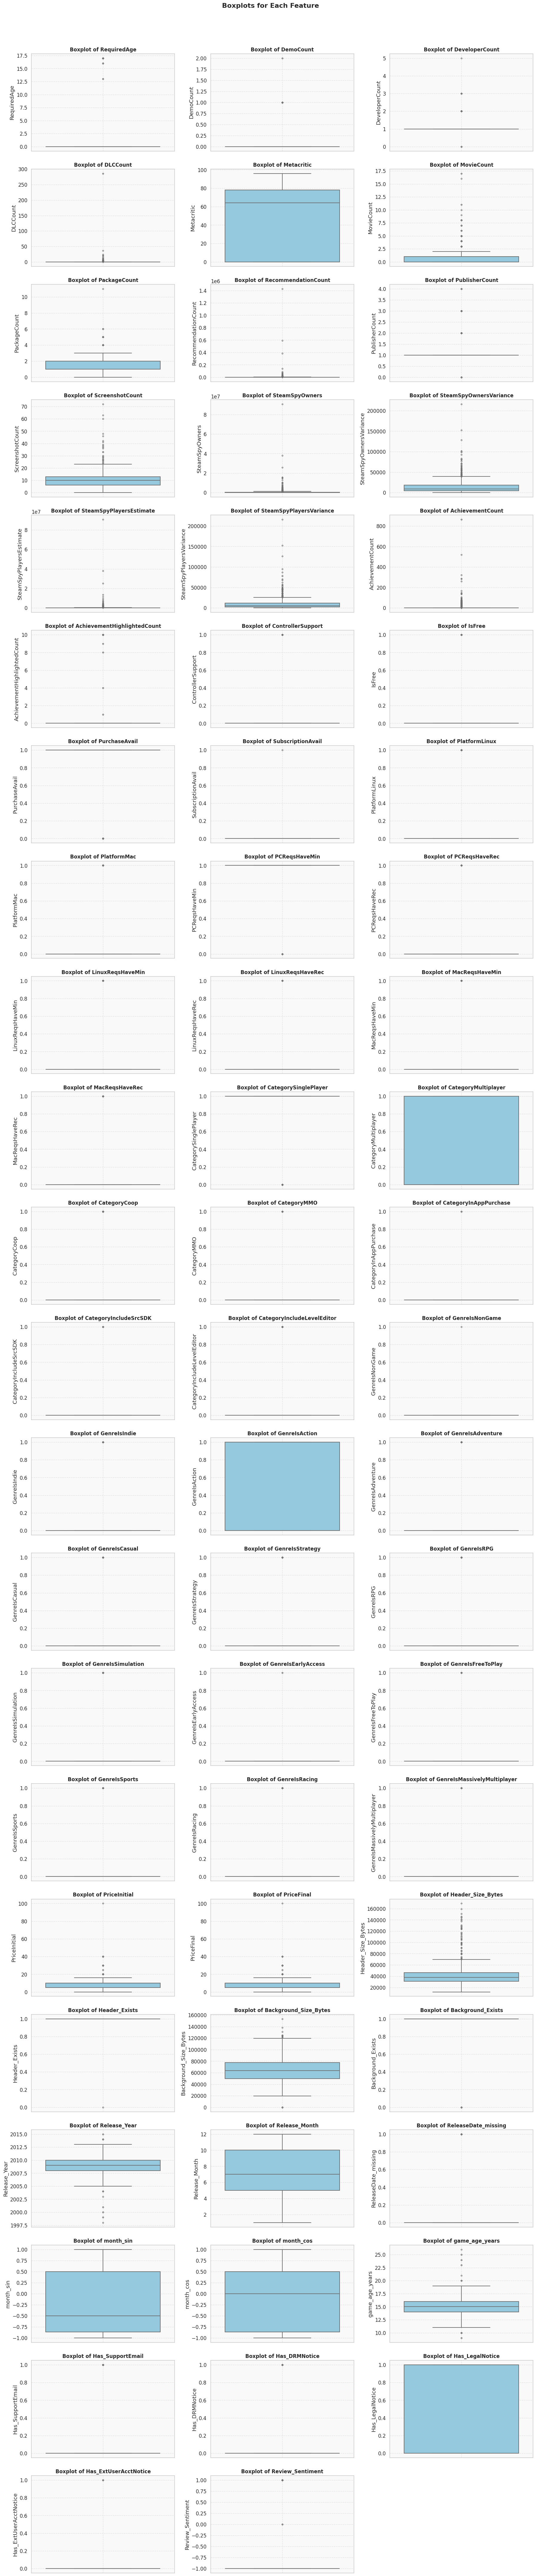

In [40]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 17-Log transform only true numeric, skewed, non-binary columns.

In [41]:
skew_threshold = 1
exclude_log_cols = set(binary_like_cols + ["Release_Year", "Release_Month"])
exclude_log_cols = {c for c in exclude_log_cols if c in df.columns}
num_cols = df.select_dtypes(include=np.number).columns.tolist()
log_cols = [
    col for col in num_cols
    if col not in exclude_log_cols
    and df[col].skew() > skew_threshold
    and (df[col] >= 0).all()]
print("Columns to log:", log_cols)
for col in log_cols:
  df[col] = np.log1p(df[col])

Columns to log: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'MovieCount', 'PackageCount', 'RecommendationCount', 'PublisherCount', 'ScreenshotCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementCount', 'AchievementHighlightedCount', 'PriceInitial', 'PriceFinal', 'Header_Size_Bytes']


### 18-Final checks.

In [42]:
print("Final shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Final shape: (942, 81)
Remaining missing values: 6347


In [43]:
df.head()

,ResponseName,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,MovieCount,PackageCount,RecommendationCount,PublisherCount,...,ReleaseDate_missing,month_sin,month_cos,game_age_years,Game_Description,Has_SupportEmail,Has_DRMNotice,Has_LegalNotice,Has_ExtUserAcctNotice,Review_Sentiment
0,Counter-Strike,0.0,0.0,0.693147,0.0,88,0.0,0.693147,11.141746,0.693147,...,0,-5.000000e-01,0.866025,24.0,Play the worlds number 1 online action game. E...,0,0,0,0,-1
1,Team Fortress Classic,0.0,0.0,0.693147,0.0,0,0.0,0.693147,7.799753,0.693147,...,0,8.660254e-01,-0.500000,25.0,One of the most popular online action games of...,0,0,0,0,-1
2,Day of Defeat,0.0,0.0,0.693147,0.0,79,0.0,0.693147,7.749322,0.693147,...,0,5.000000e-01,-0.866025,21.0,Enlist in an intense brand of Axis vs. Allied ...,0,0,0,0,-1
3,Deathmatch Classic,0.0,0.0,0.693147,0.0,0,0.0,0.693147,6.790097,0.693147,...,0,1.224647e-16,-1.000000,23.0,Enjoy fast-paced multiplayer gaming with Death...,0,0,0,0,-1
4,Half-Life: Opposing Force,0.0,0.0,0.693147,0.0,0,0.0,0.693147,7.984463,0.693147,...,0,-5.000000e-01,0.866025,25.0,Return to the Black Mesa Research Facility as ...,0,0,0,0,-1


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Data columns (total 81 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 942 non-null    object 
 1   RequiredAge                  942 non-null    float64
 2   DemoCount                    942 non-null    float64
 3   DeveloperCount               942 non-null    float64
 4   DLCCount                     942 non-null    float64
 5   Metacritic                   942 non-null    int64  
 6   MovieCount                   942 non-null    float64
 7   PackageCount                 942 non-null    float64
 8   RecommendationCount          942 non-null    float64
 9   PublisherCount               942 non-null    float64
 10  ScreenshotCount              942 non-null    float64
 11  SteamSpyOwners               942 non-null    float64
 12  SteamSpyOwnersVariance       942 non-null    float64
 13  SteamSpyPlayersEstimate  

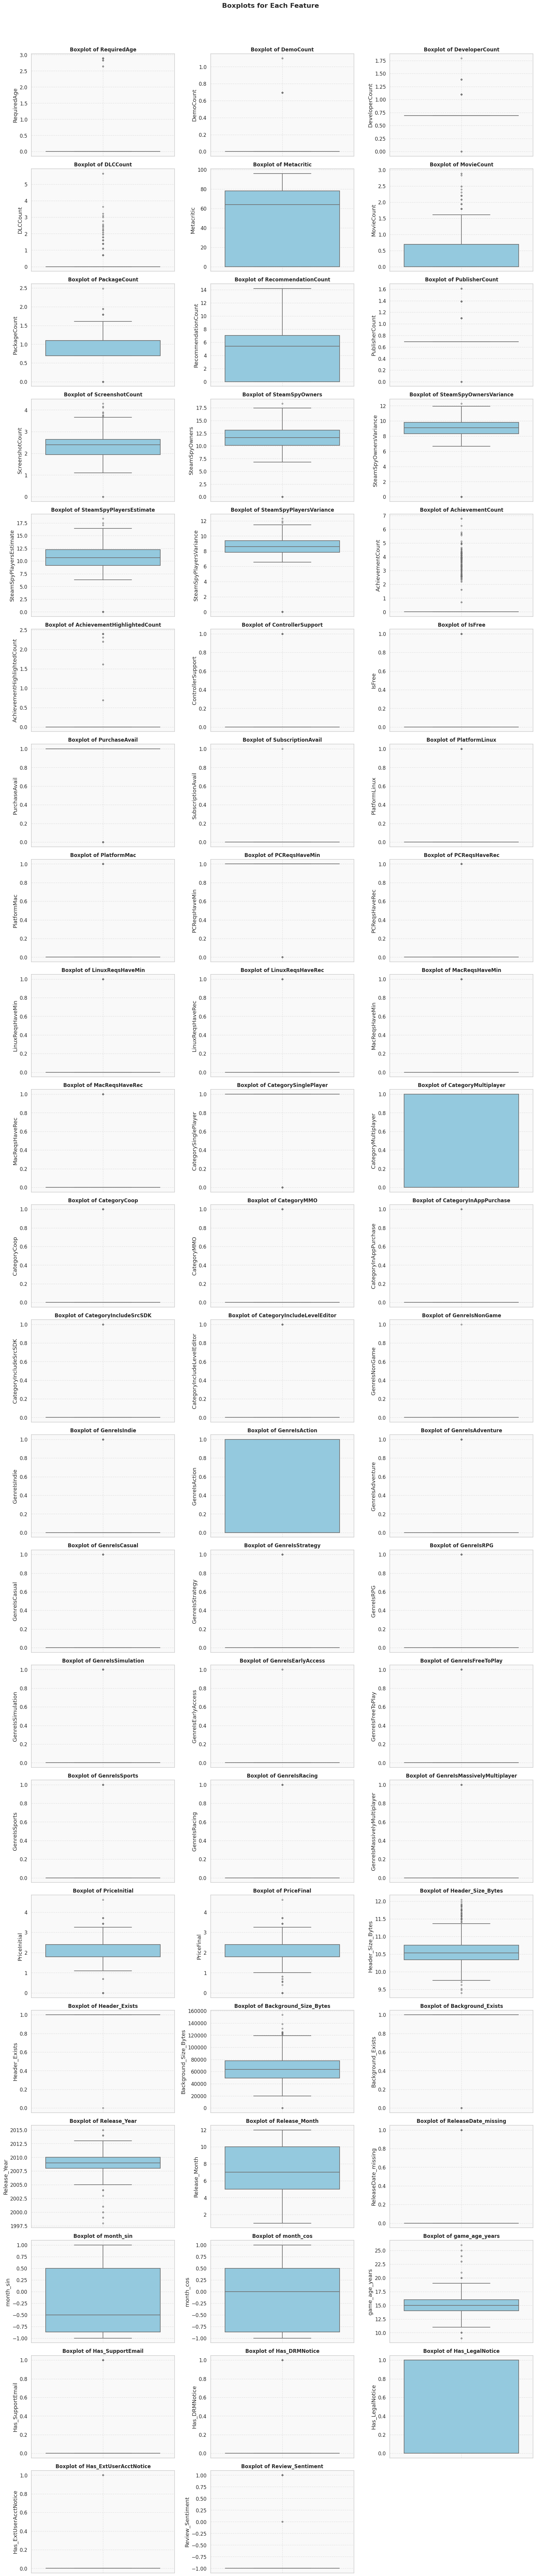

In [45]:
sns.set(style="whitegrid", font_scale=1.1)
cols = df.columns.drop(cat_cols)
n_cols = 3
n_rows = -(-len(cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', fliersize=3, linewidth=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, weight='bold')
    axes[i].set_facecolor('#f9f9f9')
    axes[i].grid(True, linestyle='--', alpha=0.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for Each Feature", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Data columns (total 81 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ResponseName                 942 non-null    object 
 1   RequiredAge                  942 non-null    float64
 2   DemoCount                    942 non-null    float64
 3   DeveloperCount               942 non-null    float64
 4   DLCCount                     942 non-null    float64
 5   Metacritic                   942 non-null    int64  
 6   MovieCount                   942 non-null    float64
 7   PackageCount                 942 non-null    float64
 8   RecommendationCount          942 non-null    float64
 9   PublisherCount               942 non-null    float64
 10  ScreenshotCount              942 non-null    float64
 11  SteamSpyOwners               942 non-null    float64
 12  SteamSpyOwnersVariance       942 non-null    float64
 13  SteamSpyPlayersEstimate  

### 19 - Cap outliers using IQR Winsorizing on skewed numeric columns

In [47]:
exclude_from_capping = (
    binary_like_cols
    + ["Release_Year", "Release_Month", "RecommendationCount"]
)
exclude_from_capping = {c for c in exclude_from_capping if c in df.columns}

# Only cap numeric columns that are still skewed after log transform
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cap_candidates = [
    col for col in num_cols
    if col not in exclude_from_capping
    and abs(df[col].skew()) > 1.0
]
print("Columns to winsorize:", cap_candidates)

capped_report = []

for col in cap_candidates:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)

    capped_report.append({
        "column": col,
        "lower_bound": round(lower, 4),
        "upper_bound": round(upper, 4),
        "outliers_capped": n_outliers,
        "skew_after": round(df[col].skew(), 4)
    })

print(pd.DataFrame(capped_report).to_string(index=False))


Columns to winsorize: ['RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'MovieCount', 'PublisherCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementCount', 'AchievementHighlightedCount', 'PriceInitial', 'PriceFinal', 'Review_Sentiment']
                     column  lower_bound  upper_bound  outliers_capped  skew_after
                RequiredAge       0.0000       0.0000              129      0.0000
                  DemoCount       0.0000       0.0000              227      0.0000
             DeveloperCount       0.6931       0.6931               55      0.0000
                   DLCCount       0.0000       0.0000               93      0.0000
                 MovieCount      -1.0397       1.7329               42      0.6418
             PublisherCount       0.6931       0.6931               83      0.0000
             SteamSpyOwners       5.6311      17.5584               47     -0.5194
     SteamSpyOwnersVaria

### 20 - Convert boolean columns to int

In [48]:
bool_cols = df.select_dtypes(include="bool").columns.tolist()

print(f"Boolean columns found: {len(bool_cols)}")
print(bool_cols)

df[bool_cols] = df[bool_cols].astype(int)

remaining_bool = df.select_dtypes(include="bool").columns.tolist()
print(f"\nBool columns remaining after conversion: {len(remaining_bool)}")
print("Sample values:")
print(df[bool_cols].head(3))

Boolean columns found: 0
[]

Bool columns remaining after conversion: 0
Sample values:
Empty DataFrame
Columns: []
Index: [0, 1, 2]


### 21 - Encode SupportedLanguages and PopularUserTags into numeric features

In [49]:
import ast

# parse the tuple-string back into a real tuple
def parse_tuple(val):
    if pd.isna(val):
        return ()
    if isinstance(val, tuple):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, tuple) else ()
    except:
        return ()

# SupportedLanguages
if "SupportedLanguages" in df.columns:
    df["SupportedLanguages"] = df["SupportedLanguages"].apply(parse_tuple)
    df["language_count"] = df["SupportedLanguages"].apply(len)
    # supports English (most common language)
    df["has_english"] = df["SupportedLanguages"].apply(
        lambda x: 1 if any("english" in lang for lang in x) else 0
    )
    # drop original tuple columns
    df.drop(columns=["SupportedLanguages"], inplace=True, errors='ignore')
else:
    # If the column is already dropped, ensure the generated columns exist with default values
    if "language_count" not in df.columns:
        df["language_count"] = 0
    if "has_english" not in df.columns:
        df["has_english"] = 0

# PopularUserTags
if "PopularUserTags" in df.columns:
    df["PopularUserTags"] = df["PopularUserTags"].apply(parse_tuple)

    df["tag_count"] = df["PopularUserTags"].apply(len)

    # Top 25 most frequent tags to binary indicator columns
    from collections import Counter

    all_tags = [tag for tags in df["PopularUserTags"] for tag in tags]
    if all_tags:
        top_tags = [tag for tag, _ in Counter(all_tags).most_common(25)]
        print("Top 25 tags:", top_tags)

        for tag in top_tags:
            col_name = f"tag_{tag.replace(' ', '_').replace('-', '_')}"
            # Check if column already exists before creating to prevent errors on rerun
            if col_name not in df.columns:
                df[col_name] = df["PopularUserTags"].apply(lambda x: 1 if tag in x else 0)
    else:
        print("No popular user tags found to extract.")

    # drop original tuple columns
    df.drop(columns=["PopularUserTags"], inplace=True, errors='ignore')
else:
    if "tag_count" not in df.columns:
        df["tag_count"] = 0


new_cols = []
if "language_count" in df.columns: new_cols.append("language_count")
if "has_english" in df.columns: new_cols.append("has_english")
if "tag_count" in df.columns: new_cols.append("tag_count")
# dynamically created tag columns
for col in df.columns:
    if col.startswith("tag_") and col not in new_cols and col != "tag_count":
        new_cols.append(col)

print(f"\nNew columns added ({len(new_cols)}):", new_cols)
# describe columns
existing_new_cols_for_describe = [col for col in new_cols if col in df.columns]
if existing_new_cols_for_describe:
    print(df[existing_new_cols_for_describe].describe())
else:
    print("No new tag/language columns to describe.")

Top 25 tags: ['singleplayer', 'action', 'strategy', 'multiplayer', 'adventure', 'shooter', 'casual', 'classic', 'server err', 'fps', 'first-person', 'puzzle', 'simulation', 'sci-fi', 'rpg', 'indie', 'third person', 'fantasy', 'open world', 'co-op', 'rts', 'point & click', 'story rich', 'historical', 'comedy']

New columns added (28): ['language_count', 'has_english', 'tag_count', 'tag_singleplayer', 'tag_action', 'tag_strategy', 'tag_multiplayer', 'tag_adventure', 'tag_shooter', 'tag_casual', 'tag_classic', 'tag_server_err', 'tag_fps', 'tag_first_person', 'tag_puzzle', 'tag_simulation', 'tag_sci_fi', 'tag_rpg', 'tag_indie', 'tag_third_person', 'tag_fantasy', 'tag_open_world', 'tag_co_op', 'tag_rts', 'tag_point_&_click', 'tag_story_rich', 'tag_historical', 'tag_comedy']
       language_count  has_english   tag_count  tag_singleplayer  tag_action  \
count      942.000000   942.000000  942.000000        942.000000  942.000000   
mean         1.491507     0.991507    6.530786          0.44

/tmp/ipykernel_2300/884273350.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df["PopularUserTags"].apply(lambda x: 1 if tag in x else 0)
/tmp/ipykernel_2300/884273350.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df["PopularUserTags"].apply(lambda x: 1 if tag in x else 0)
/tmp/ipykernel_2300/884273350.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

### 22 - Drop pure identifier and already-flagged text columns

In [50]:
# near-unique identifier, so, it cannot be encoded meaningfully
df.drop(columns=["ResponseName"], inplace=True, errors='ignore')

# Has_SupportEmail already encodes presence of SupportEmail
df.drop(columns=["SupportEmail"], inplace=True, errors='ignore')

# Has_LegalNotice already encodes presence of SupportEmail
df.drop(columns=["LegalNotice"], inplace=True, errors='ignore')

print("Current shape:", df.shape)

Current shape: (942, 104)


 ### 23 - Extract features from PCMinReqsText

In [51]:
import re

# Extraction functions
def extract_ram_gb(text):
    if pd.isna(text): return np.nan
    text = text.lower()
    m = re.search(r'(\d+(?:\.\d+)?)\s*gb', text)
    if m: return float(m.group(1))
    m = re.search(r'(\d+(?:\.\d+)?)\s*mb', text)
    if m: return round(float(m.group(1)) / 1024, 4)
    return np.nan

def has_directx(text):
    if pd.isna(text): return 0
    return 1 if "directx" in text.lower() else 0

# Extract features
df["pc_min_ram_gb"]    = df["PCMinReqsText"].apply(extract_ram_gb)
df["pc_min_word_count"] = df["PCMinReqsText"].fillna("").apply(lambda x: len(x.split()))
df["pc_min_has_directx"]= df["PCMinReqsText"].apply(has_directx)

# Fill missing RAM with median
ram_median = df["pc_min_ram_gb"].median()
df["pc_min_ram_gb"] = df["pc_min_ram_gb"].fillna(ram_median)

# dropping raw column
df.drop(columns=["PCMinReqsText"], inplace=True)
print("Current shape:", df.shape)


/tmp/ipykernel_2300/3172442894.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pc_min_ram_gb"]    = df["PCMinReqsText"].apply(extract_ram_gb)


Current shape: (942, 106)


/tmp/ipykernel_2300/3172442894.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pc_min_word_count"] = df["PCMinReqsText"].fillna("").apply(lambda x: len(x.split()))
/tmp/ipykernel_2300/3172442894.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pc_min_has_directx"]= df["PCMinReqsText"].apply(has_directx)


### 24 - Extract features from PCRecReqsText, justify, then drop.

In [52]:
# feature 1: has_pc_rec_reqs — does the game bother to list rec specs?
df["has_pc_rec_reqs"] = df["PCRecReqsText"].notna().astype(int)

# feature 2: pc_rec_ram_gb — recommended RAM where available
df["pc_rec_ram_gb"] = df["PCRecReqsText"].apply(extract_ram_gb)
ram_rec_median = df["pc_rec_ram_gb"].median()
df["pc_rec_ram_gb"] = df["pc_rec_ram_gb"].fillna(ram_rec_median)

# feature 3: pc_rec_word_count — complexity of recommended spec
df["pc_rec_word_count"] = df["PCRecReqsText"].fillna("").apply(lambda x: len(x.split()))

# dopping raw column
df.drop(columns=["PCRecReqsText"], inplace=True)

# Compare rec RAM vs min RAM
print("Correlation between pc_rec_ram_gb and pc_min_ram_gb:",
      round(df["pc_rec_ram_gb"].corr(df["pc_min_ram_gb"]), 4))

Correlation between pc_rec_ram_gb and pc_min_ram_gb: 0.0213


/tmp/ipykernel_2300/1969048243.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_pc_rec_reqs"] = df["PCRecReqsText"].notna().astype(int)
/tmp/ipykernel_2300/1969048243.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pc_rec_ram_gb"] = df["PCRecReqsText"].apply(extract_ram_gb)
/tmp/ipykernel_2300/1969048243.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

### 25 - Extract features from MacMinReqsText

In [53]:
# LinuxMinReqsText
non_null_count = df["LinuxMinReqsText"].notna().sum()
# most rows are null, so, any extracted numeric feature would be, median-filled making it near-constant.
# A binary flag is the only honest signal
df["has_linux_min_reqs"] = df["LinuxMinReqsText"].notna().astype(int)
# drop raw col
df.drop(columns=["LinuxMinReqsText"], inplace=True)


# MacMinReqsText
non_null_count = df["MacMinReqsText"].notna().sum()
# same as LinuxMinReqsText
df["has_mac_min_reqs"] = df["MacMinReqsText"].notna().astype(int)
df.drop(columns=["MacMinReqsText"], inplace=True)

# Correlation between Linux and mac
corr_linux = df["has_mac_min_reqs"].corr(df["has_linux_min_reqs"])
print(f"Corr of has_mac_min_reqs with has_linux_min_reqs : {corr_linux:.4f}")

Corr of has_mac_min_reqs with has_linux_min_reqs : 0.5190


/tmp/ipykernel_2300/1035583986.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_linux_min_reqs"] = df["LinuxMinReqsText"].notna().astype(int)
/tmp/ipykernel_2300/1035583986.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_mac_min_reqs"] = df["MacMinReqsText"].notna().astype(int)


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Columns: 108 entries, RequiredAge to has_mac_min_reqs
dtypes: Int64(2), float64(24), int64(75), object(7)
memory usage: 836.3+ KB


### 26 - Semantic Embeddings of Game_Description.

In [55]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

model = SentenceTransformer("all-MiniLM-L6-v2")

emb = model.encode(
    df["Game_Description"].fillna("").tolist(),
    convert_to_numpy=True
)

train_mask = df.index.isin(train_idx)

# Fixed at 30 components (variance is flat beyond this point)
n_components = 30
pca = PCA(n_components=n_components)
pca.fit(emb[train_mask])
desc_all = pca.transform(emb)

for i in range(n_components):
    df[f"desc_semantic_{i}"] = desc_all[:, i]

df.drop(columns=["Game_Description"], inplace=True)

print(f"Added {n_components} semantic features.")
print(f"Variance captured : {pca.explained_variance_ratio_.sum():.3f}")
print(f"Per-component variance (first 10):")
for i, v in enumerate(pca.explained_variance_ratio_[:10]):
    print(f"  desc_semantic_{i}: {v:.4f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Added 30 semantic features.
Variance captured : 0.508
Per-component variance (first 10):
  desc_semantic_0: 0.0573
  desc_semantic_1: 0.0385
  desc_semantic_2: 0.0355
  desc_semantic_3: 0.0307
  desc_semantic_4: 0.0252
  desc_semantic_5: 0.0240
  desc_semantic_6: 0.0229
  desc_semantic_7: 0.0207
  desc_semantic_8: 0.0180
  desc_semantic_9: 0.0166


/tmp/ipykernel_2300/1087295057.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"desc_semantic_{i}"] = desc_all[:, i]
/tmp/ipykernel_2300/1087295057.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"desc_semantic_{i}"] = desc_all[:, i]
/tmp/ipykernel_2300/1087295057.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fram

In [56]:
# Show added semantic description features
semantic_features = [col for col in df.columns if col.startswith("desc_semantic_")]

print(f"Number of features added: {len(semantic_features)}")
print("\nAdded features:")
for f in semantic_features:
    print(f)

# preview values
print("\nSample values:")
print(df[semantic_features].head())

# how much information the 10 features keep
print("\nExplained variance ratio:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"desc_semantic_{i}: {v:.4f}")

print("\nTotal variance captured:",
      round(pca.explained_variance_ratio_.sum(),4))

Number of features added: 30

Added features:
desc_semantic_0
desc_semantic_1
desc_semantic_2
desc_semantic_3
desc_semantic_4
desc_semantic_5
desc_semantic_6
desc_semantic_7
desc_semantic_8
desc_semantic_9
desc_semantic_10
desc_semantic_11
desc_semantic_12
desc_semantic_13
desc_semantic_14
desc_semantic_15
desc_semantic_16
desc_semantic_17
desc_semantic_18
desc_semantic_19
desc_semantic_20
desc_semantic_21
desc_semantic_22
desc_semantic_23
desc_semantic_24
desc_semantic_25
desc_semantic_26
desc_semantic_27
desc_semantic_28
desc_semantic_29

Sample values:
   desc_semantic_0  desc_semantic_1  desc_semantic_2  desc_semantic_3  \
0        -0.312854         0.054664         0.006290        -0.042153   
1        -0.294157         0.123213         0.083834        -0.081047   
2        -0.481501        -0.044904         0.147621         0.090011   
3        -0.065885         0.159893         0.200182        -0.050989   
4        -0.045217        -0.005870         0.114932         0.081952   


### Drop very high-missing columns that are not raw text columns.

In [57]:
missing_ratio = df.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.80].index.tolist()
if high_missing_cols:
  print("Dropped high-missing columns:", high_missing_cols)
  df.drop(columns=high_missing_cols, inplace=True)

Dropped high-missing columns: ['DRMNotice', 'LinuxRecReqsText', 'MacRecReqsText']


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Columns: 134 entries, RequiredAge to desc_semantic_29
dtypes: Int64(2), float32(30), float64(24), int64(75), object(3)
memory usage: 917.3+ KB


### Composite Feature Engineering

In [59]:
# Price discount signal
if {"PriceInitial", "PriceFinal"}.issubset(df.columns):
    df["has_discount"]    = (df["PriceInitial"] != df["PriceFinal"]).astype(int)
    df["discount_amount"] = (df["PriceInitial"] - df["PriceFinal"]).clip(lower=0)

# Platform breadth (wider platform support = wider audience)
platform_cols = [c for c in ["PlatformWindows", "PlatformLinux", "PlatformMac"] if c in df.columns]
df["platform_count"] = df[platform_cols].sum(axis=1)

# Category and genre richness
category_cols = [c for c in df.columns if c.startswith("Category")]
genre_cols    = [c for c in df.columns if c.startswith("Genre")]
df["category_count"] = df[category_cols].sum(axis=1)
df["genre_count"]    = df[genre_cols].sum(axis=1)

# Log-scale language count (right-skewed)
if "language_count" in df.columns:
    df["language_count_log"] = np.log1p(df["language_count"])

new_feats = ["has_discount", "discount_amount", "platform_count",
             "category_count", "genre_count", "language_count_log"]
print("Composite features added:")
print(df[[f for f in new_feats if f in df.columns]].describe().round(2))

Composite features added:
       has_discount  discount_amount  platform_count  category_count  \
count        942.00           942.00          942.00          942.00   
mean           0.02             0.02            0.29            1.52   
std            0.13             0.13            0.61            0.78   
min            0.00             0.00            0.00            0.00   
25%            0.00             0.00            0.00            1.00   
50%            0.00             0.00            0.00            1.00   
75%            0.00             0.00            0.00            2.00   
max            1.00             1.32            2.00            4.00   

       genre_count  language_count_log  
count       942.00              942.00  
mean          1.44                0.82  
std           0.72                0.37  
min           0.00                0.00  
25%           1.00                0.69  
50%           1.00                0.69  
75%           2.00                0.69

/tmp/ipykernel_2300/1674372388.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_discount"]    = (df["PriceInitial"] != df["PriceFinal"]).astype(int)
/tmp/ipykernel_2300/1674372388.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["discount_amount"] = (df["PriceInitial"] - df["PriceFinal"]).clip(lower=0)
/tmp/ipykernel_2300/1674372388.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

### Encoding

In [60]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns remaining: {len(categorical_cols)}")
explore_categorical = pd.DataFrame({"data_type": df[categorical_cols].dtypes, "unique_values": [df[c].nunique() for c in categorical_cols],"unique_set": [df[c].unique()[:5] for c in categorical_cols]})
print(explore_categorical)

Categorical columns remaining: 3
                  data_type  unique_values  \
Support_Tier         object              3   
Header_Size_Group    object              4   
Website_Authority    object              3   

                                                          unique_set  
Support_Tier       [Community_Social, Professional_Portal, Genera...  
Header_Size_Group                [Small, Medium, Large, Extra_Large]  
Website_Authority  [Custom_Studio, Major_Publisher, Has_Social_Only]  


In [61]:
df[categorical_cols].head()

,Support_Tier,Header_Size_Group,Website_Authority
0,Community_Social,Small,Custom_Studio
1,Professional_Portal,Small,Custom_Studio
2,Professional_Portal,Medium,Custom_Studio
3,Professional_Portal,Small,Custom_Studio
4,Professional_Portal,Medium,Custom_Studio


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Columns: 140 entries, RequiredAge to language_count_log
dtypes: Int64(2), float32(30), float64(26), int64(79), object(3)
memory usage: 961.4+ KB


In [63]:
# Header_Size_Group >> ordinal encoding
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
from sklearn.preprocessing import OrdinalEncoder

size_order = ['Small', 'Medium', 'Large', 'Extra_Large']
encoder = OrdinalEncoder(categories=[size_order])
df['Header_Size_Group'] = encoder.fit_transform(df[['Header_Size_Group']])


In [64]:
df["Header_Size_Group"].head()

,Header_Size_Group
0,0.0
1,0.0
2,1.0
3,0.0
4,1.0


In [65]:
# Support_Tier — one-hot encode
if "Support_Tier" in df.columns:
    support_dummies = pd.get_dummies(df["Support_Tier"], prefix="Support_Tier", drop_first=True)
    df = pd.concat([df, support_dummies], axis=1)
    df.drop(columns=["Support_Tier"], inplace=True)

# Website_Authority — one-hot encode
if "Website_Authority" in df.columns:
    website_dummies = pd.get_dummies(df["Website_Authority"], prefix="Website_Authority", drop_first=True)
    df = pd.concat([df, website_dummies], axis=1)
    df.drop(columns=["Website_Authority"], inplace=True)

# Encode any remaining object columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Encoded {len(categorical_cols)} remaining categorical columns.")

print("Shape after all encoding:", df.shape)
print("Remaining object columns:", df.select_dtypes(include="object").columns.tolist())

Shape after all encoding: (942, 142)
Remaining object columns: []


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 942 entries, 0 to 980
Columns: 142 entries, RequiredAge to Website_Authority_Major_Publisher
dtypes: Int64(2), bool(4), float32(30), float64(27), int64(79)
memory usage: 950.4 KB


In [67]:
# standard scaler for numeric features except the binary-like ones and the release date parts >>ml models
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #>> for x_train and y_train after splitting, to avoid data leakage




In [68]:
# just assembles train/test from existing indices
x = df.drop(columns=["RecommendationCount"])
y = df["RecommendationCount"]

x_train = x.loc[train_idx].reset_index(drop=True)
x_test  = x.loc[test_idx].reset_index(drop=True)
y_train = y.loc[train_idx].reset_index(drop=True)
y_test  = y.loc[test_idx].reset_index(drop=True)

print(f"x_train: {x_train.shape} | x_test: {x_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

x_train: (753, 141) | x_test: (189, 141)
y_train: (753,) | y_test: (189,)


### Feature selection

In [69]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train, y_train)

importances = model.feature_importances_

In [70]:
# Step 1 - See the importance of each feature
feature_names = x_train.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df)

                         Feature  Importance
12       SteamSpyPlayersVariance    0.383384
11       SteamSpyPlayersEstimate    0.370761
67                     tag_count    0.051332
104              desc_semantic_3    0.008880
54                  Release_Year    0.008521
..                           ...         ...
64              Review_Sentiment    0.000000
13              AchievementCount    0.000000
66                   has_english    0.000000
50                 Header_Exists    0.000000
14   AchievementHighlightedCount    0.000000

[141 rows x 2 columns]


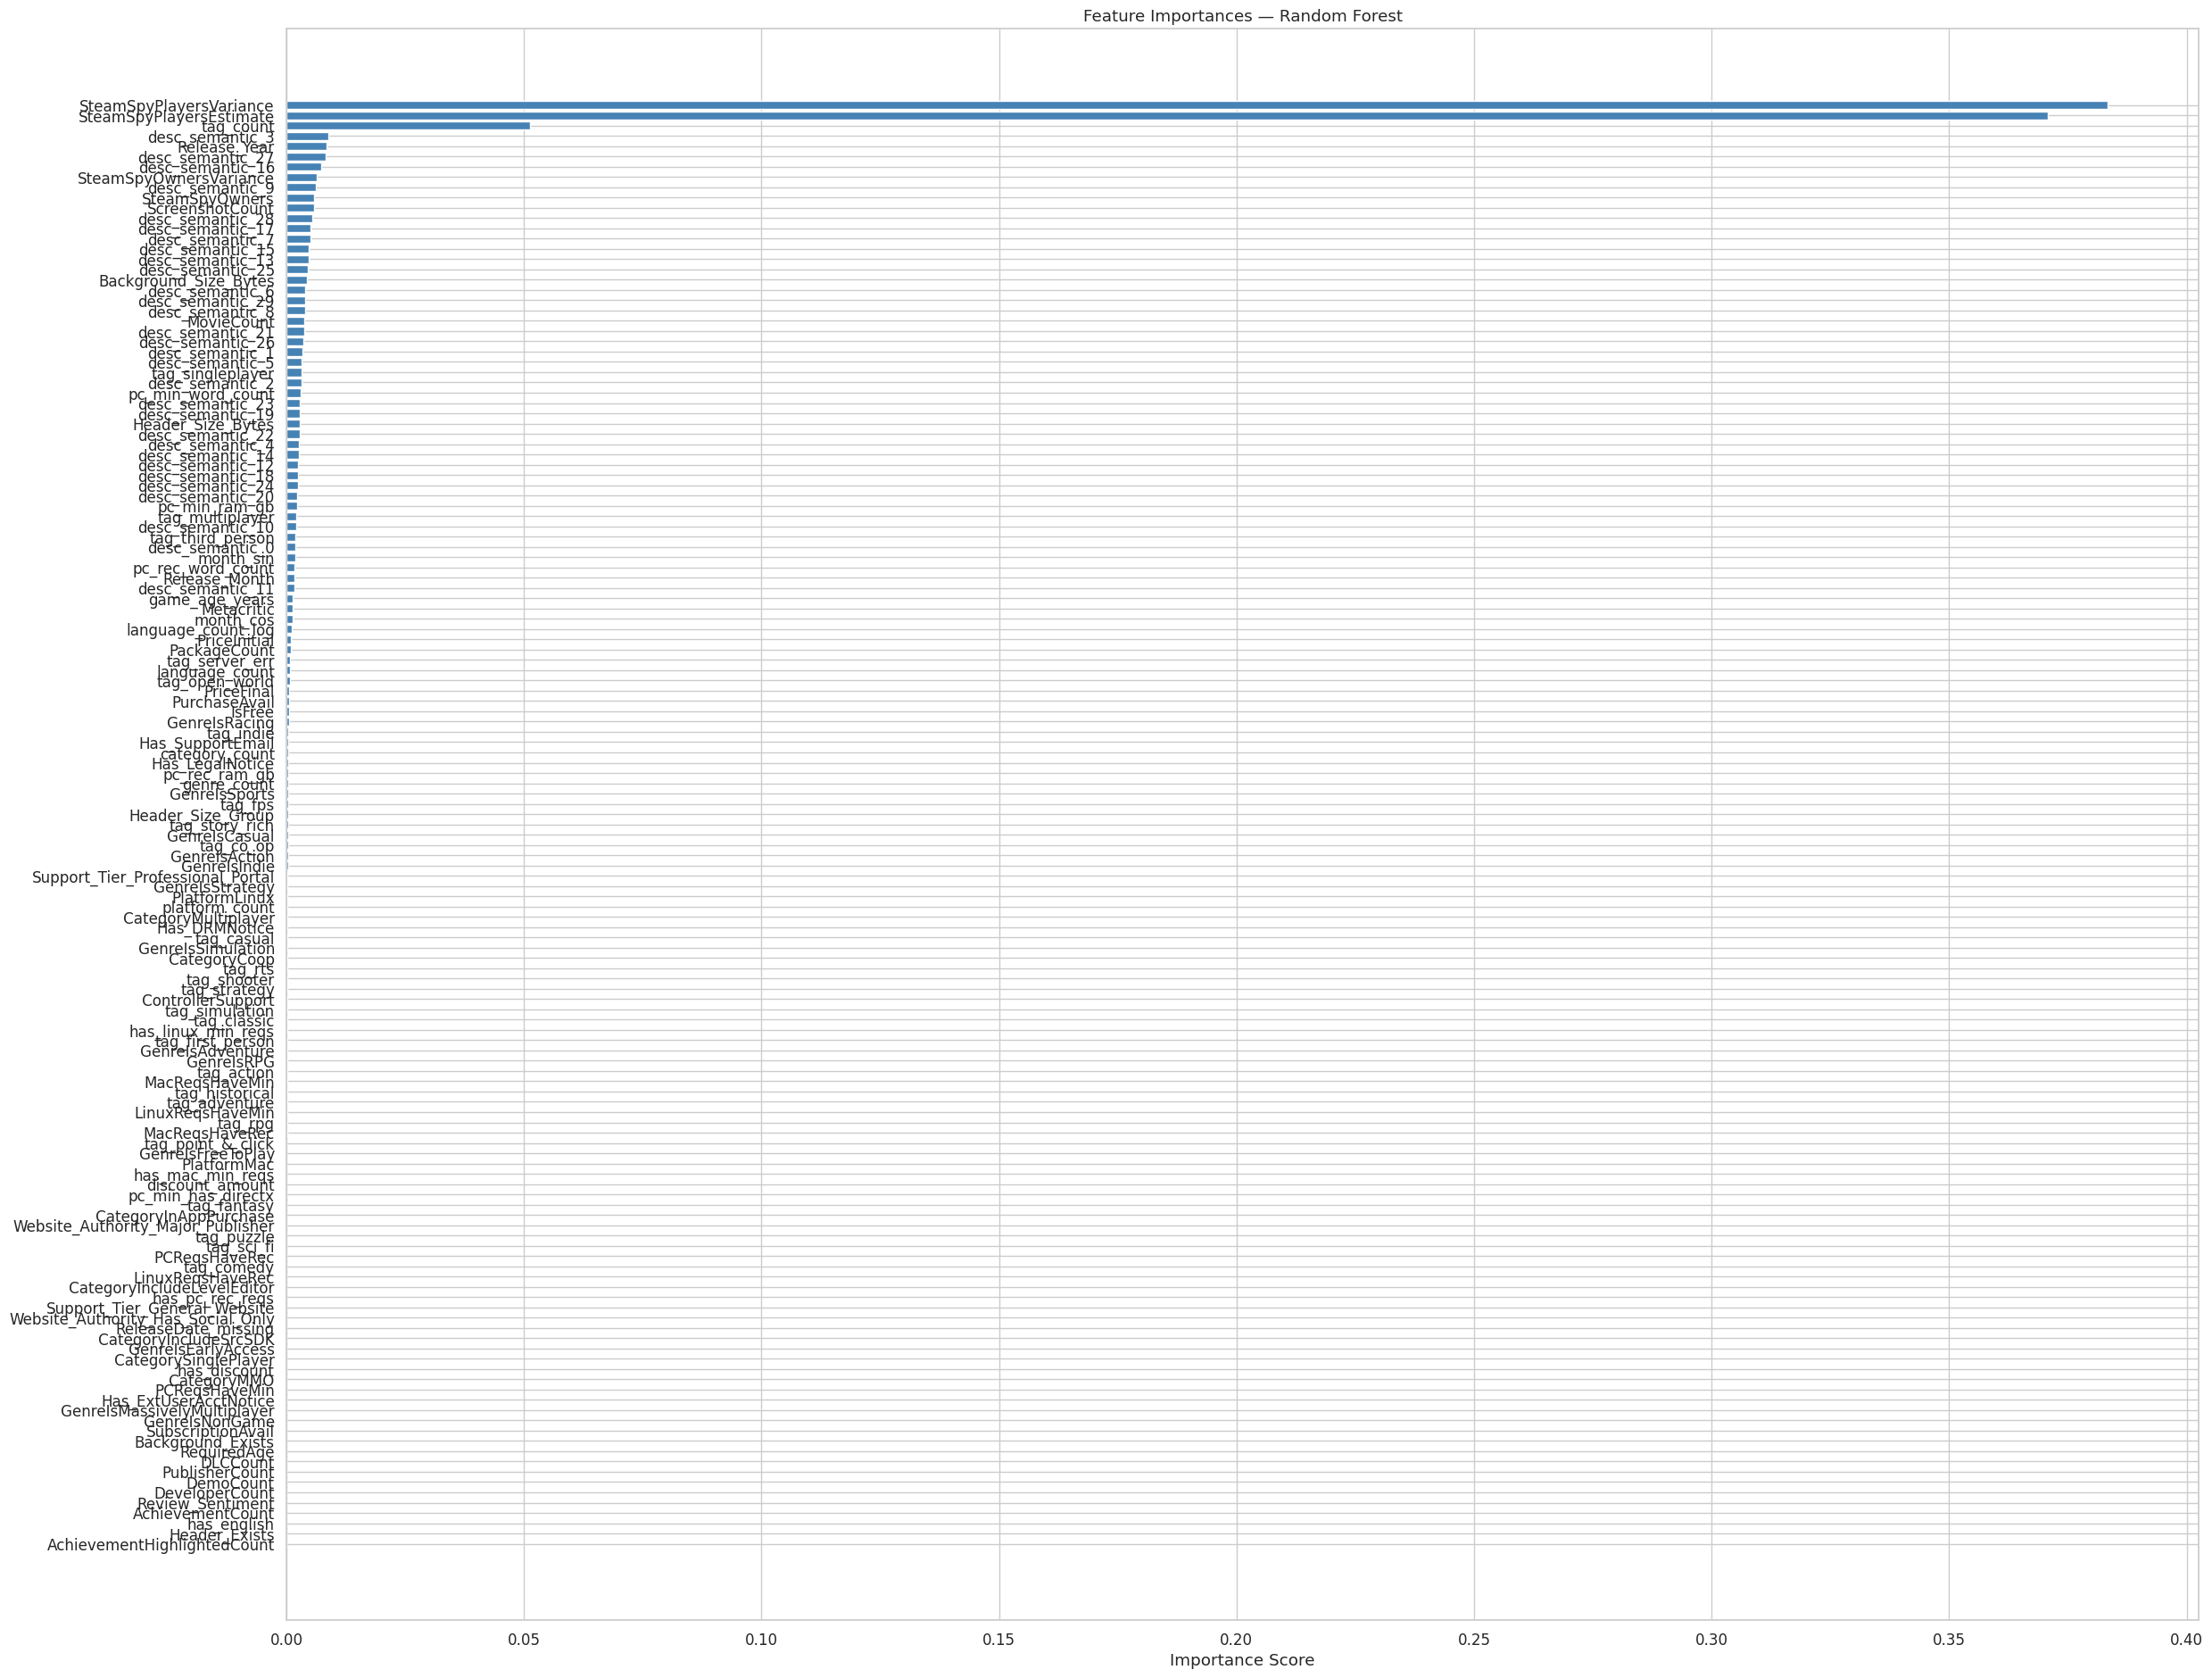

In [71]:
# Step 2 - Plot the importances
plt.figure(figsize=(25, 19))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importances — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [72]:
# Step 3 - Keep only features above threshold

importance_df = importance_df.sort_values("Importance", ascending=False).reset_index(drop=True)
importance_df["cumulative_importance"] = importance_df["Importance"].cumsum()

selected_features = importance_df[
    importance_df["cumulative_importance"] <= 0.95
]["Feature"].tolist()

# include the feature that crosses the 95% threshold
if len(selected_features) < len(importance_df):
    selected_features.append(importance_df.iloc[len(selected_features)]["Feature"])

print(f"Selected {len(selected_features)} features covering 95% cumulative importance")
print(importance_df[["Feature", "Importance", "cumulative_importance"]].head(20).to_string())

x_train = x_train[selected_features]
x_test  = x_test[selected_features]
print("New x_train shape:", x_train.shape)
print('New x_test shape :', x_test.shape)

Selected 35 features covering 95% cumulative importance
                    Feature  Importance  cumulative_importance
0   SteamSpyPlayersVariance    0.383384               0.383384
1   SteamSpyPlayersEstimate    0.370761               0.754146
2                 tag_count    0.051332               0.805478
3           desc_semantic_3    0.008880               0.814358
4              Release_Year    0.008521               0.822879
5          desc_semantic_27    0.008328               0.831208
6          desc_semantic_16    0.007244               0.838452
7    SteamSpyOwnersVariance    0.006460               0.844912
8           desc_semantic_9    0.006113               0.851025
9            SteamSpyOwners    0.005783               0.856808
10          ScreenshotCount    0.005757               0.862565
11         desc_semantic_28    0.005511               0.868076
12         desc_semantic_17    0.005095               0.873172
13          desc_semantic_7    0.005047               0.878218

### Feature Scaling

In [73]:
# Binary 0/1 features must not be scaled (scaling distorts their meaning)
binary_selected  = [f for f in selected_features
                    if set(x_train[f].dropna().unique()).issubset({0, 1, 0.0, 1.0})]
numeric_selected = [f for f in selected_features if f not in binary_selected]

print(f"Binary features (not scaled) : {len(binary_selected)}")
print(f"Numeric features (scaled)    : {len(numeric_selected)}")

scaler = StandardScaler()
x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[numeric_selected] = scaler.fit_transform(x_train[numeric_selected])
x_test_scaled[numeric_selected]  = scaler.transform(x_test[numeric_selected])

print("Scaled shapes:", x_train_scaled.shape, x_test_scaled.shape)

Binary features (not scaled) : 1
Numeric features (scaled)    : 34
Scaled shapes: (753, 35) (189, 35)


In [74]:
df.to_csv('data_preprocessed.csv', index=False)

In [75]:
from google.colab import files
files.download('data_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>